### Lab 7 ###
Christopher Cook, Davis Lynn, Anekah Kelley, Bonita Davis

In this lab, you will select a prediction task to perform on your dataset, evaluate a sequential architecture and tune hyper-parameters. If any part of the assignment is not clear, ask the instructor to clarify.

__Preparation__ 

[1]Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed). Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). Discuss methods of tokenization in your dataset as well as any decisions to force a specific length of sequence.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import itertools
import tensorflow as tf
import nltk
from tqdm import tqdm

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dropout, Layer, TextVectorization, Dense, GlobalMaxPooling1D, MultiHeadAttention, LayerNormalization # type: ignore
from tensorflow.keras.regularizers import l1_l2 
from nltk.corpus import stopwords
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from keras.layers import Embedding # type: ignore

mpl.style.use("seaborn-v0_8-deep")
mpl.rcParams["figure.figsize"] = (20, 5)
mpl.rcParams["figure.dpi"] = 100
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("stopwords")

nltk.data.path.append('/users/cdcook/nltk_data/tokenizers/punkt')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /users/cdcook/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /users/cdcook/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /users/cdcook/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [68]:
# Load dataset
df = pd.read_csv("./file.csv")
og_shape = df.shape
print(og_shape)

(219294, 3)


In [69]:
df

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad
...,...,...,...
219289,219289,Other Software Projects Are Now Trying to Repl...,bad
219290,219290,I asked #ChatGPT to write a #NYE Joke for SEOs...,good
219291,219291,chatgpt is being disassembled until it can onl...,bad
219292,219292,2023 predictions by #chatGPT. Nothing really s...,bad


In [70]:
def cleanText(txt):
      
    #Creates list of possible stopwords from nltk library
    stop = stopwords.words('english')
    
    # Lowercase
    txt = txt.lower()
    
    # Remove stopwords
    txt = ' '.join([word for word in txt.split() if word not in (stop)])
    
    # Remove non-alphabetic characters
    txt = re.sub('[^a-z]',' ',txt)
    return txt  

def cleanNumbers(x):
    digit_map = {
        '0': 'zero',
        '1': 'one',
        '2': 'two',
        '3': 'three',
        '4': 'four',
        '5': 'five',
        '6': 'six',
        '7': 'seven',
        '8': 'eight',
        '9': 'nine'
    }
    
    x = re.sub('[0-9]{7,}', 'millions', x)
    x = re.sub('[0-9]{4,6}', 'thousand', x)
    x = re.sub('[0-9]{3}', 'hundred', x)
    x = re.sub('[0-9]{2}', 'tens', x)
    x = re.sub('[0-9]{1}', 'tens', x)
    x = re.sub(r'\b\d\b', lambda match: digit_map[match.group()], x)

    return x
contraction_dict = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}

def _get_contractions(contraction_dict):
    contraction_re = re.compile('(%s)' % '|'.join(contraction_dict.keys()))
    return contraction_dict, contraction_re

contractions, contractions_re = _get_contractions(contraction_dict)

def replaceContractions(text):
    def replace(match):
        return contractions[match.group(0)]
    return contractions_re.sub(replace, text)


size_mini = 1000

def pre_process(df):
    """
    Parameters:
    - df (pd.Dataframe): The DataFrame to be preprocessed

    Returns: 
    - df (pd.DataFrame): The DataFrame after preprocessed

    """
    # Remove the 'Unnamed: 0' column, if it exists, as it's usually an artifact
    df = df.drop(["Unnamed: 0"], axis=1)
    
    # Map 'labels' values from 'bad'/'good' to 1/0, and set 'neutral' to NaN
    df["labels"] = df["labels"].map({"bad": 1, "good": 0, "neutral": None})
    
    # Drop rows with NaN values in 'labels'
    df = df.dropna(subset=["labels"])

    print("We have kept", (df.shape[0]/og_shape[0])*100, "% of the data")

    # Cleaning the text, numbers, and replacing contractions
    df['tweets'] = df['tweets'].apply(cleanText)
    df['tweets'] = df["tweets"].apply(cleanNumbers)
    df['tweets'] = df["tweets"].apply(replaceContractions)

    return df

In [71]:
def num_characters(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of characters in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """

    df["Characters"] = df[col_name].apply(len)
    return df


def num_sentences(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of sentences in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Sentences"] = df[col_name].apply(lambda x: len(nltk.sent_tokenize(x)))
    return df


def num_words(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of words in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Words"] = df[col_name].apply(lambda x: len(nltk.word_tokenize(x)))
    return df

In [72]:
df = pre_process(df)

We have kept 74.69743814240243 % of the data


In [73]:
df = num_characters(df, "tweets")
df = num_sentences(df, "tweets")
df = num_words(df, "tweets")
df

,tweets,labels,Characters,Sentences,Words
1,try talking chatgpt new ai system optimized d...,0.0,107,1,19
3,thrilled share chatgpt new model optimized di...,0.0,158,1,24
4,minutes ago openai released new chatgpt ...,1.0,112,1,21
5,launched chatgpt new ai system optimized dial...,0.0,113,1,22
6,minutes ago openai released new chatgpt ...,1.0,144,1,31
...,...,...,...,...,...
219287,one new favorite thing chatgpt create playlis...,0.0,189,1,30
219289,software projects trying replicate chatgpt htt...,1.0,66,1,9
219290,asked chatgpt write nye joke seos delivered ...,0.0,185,1,29
219291,chatgpt disassembled dissemble,1.0,30,1,3


In [74]:
def plot_distribution_features(df, features, col_name):
    """
    Plot distributions of specified features in a DataFrame, comparing positive and negative tweets.

    Parameters:
    - df: DataFrame containing the data.
    - features: List of strings, names of the columns for which to plot the distributions.

    Each feature's distribution is plotted in a separate row, with 'good' tweets in blue and 'bad' tweets in pink.
    """
    # Create a figure with subplots arranged in 3 rows and 1 column
    fig, axes = plt.subplots(
        nrows=len(features), ncols=1, figsize=(15, 6 * len(features))
    )

    for i, feature in enumerate(features):
        # Plot distribution for 'good' tweets
        sns.histplot(
            df[df["labels"] == 0][feature],
            kde=True,
            color="#66b3ff",
            label="Positive",
            ax=axes[i],
        )
        # Plot distribution for 'bad' tweets
        sns.histplot(
            df[df["labels"] == 1][feature],
            kde=True,
            color="#ff9999",
            label="Negative",
            ax=axes[i],
        )
        # Setting the title for each subplot
        axes[i].set_title(f"{feature} Distribution for {col_name} dataset")
        # Setting the labels for each subplot
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Count")
        # Adding legend to each subplot
        axes[i].legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

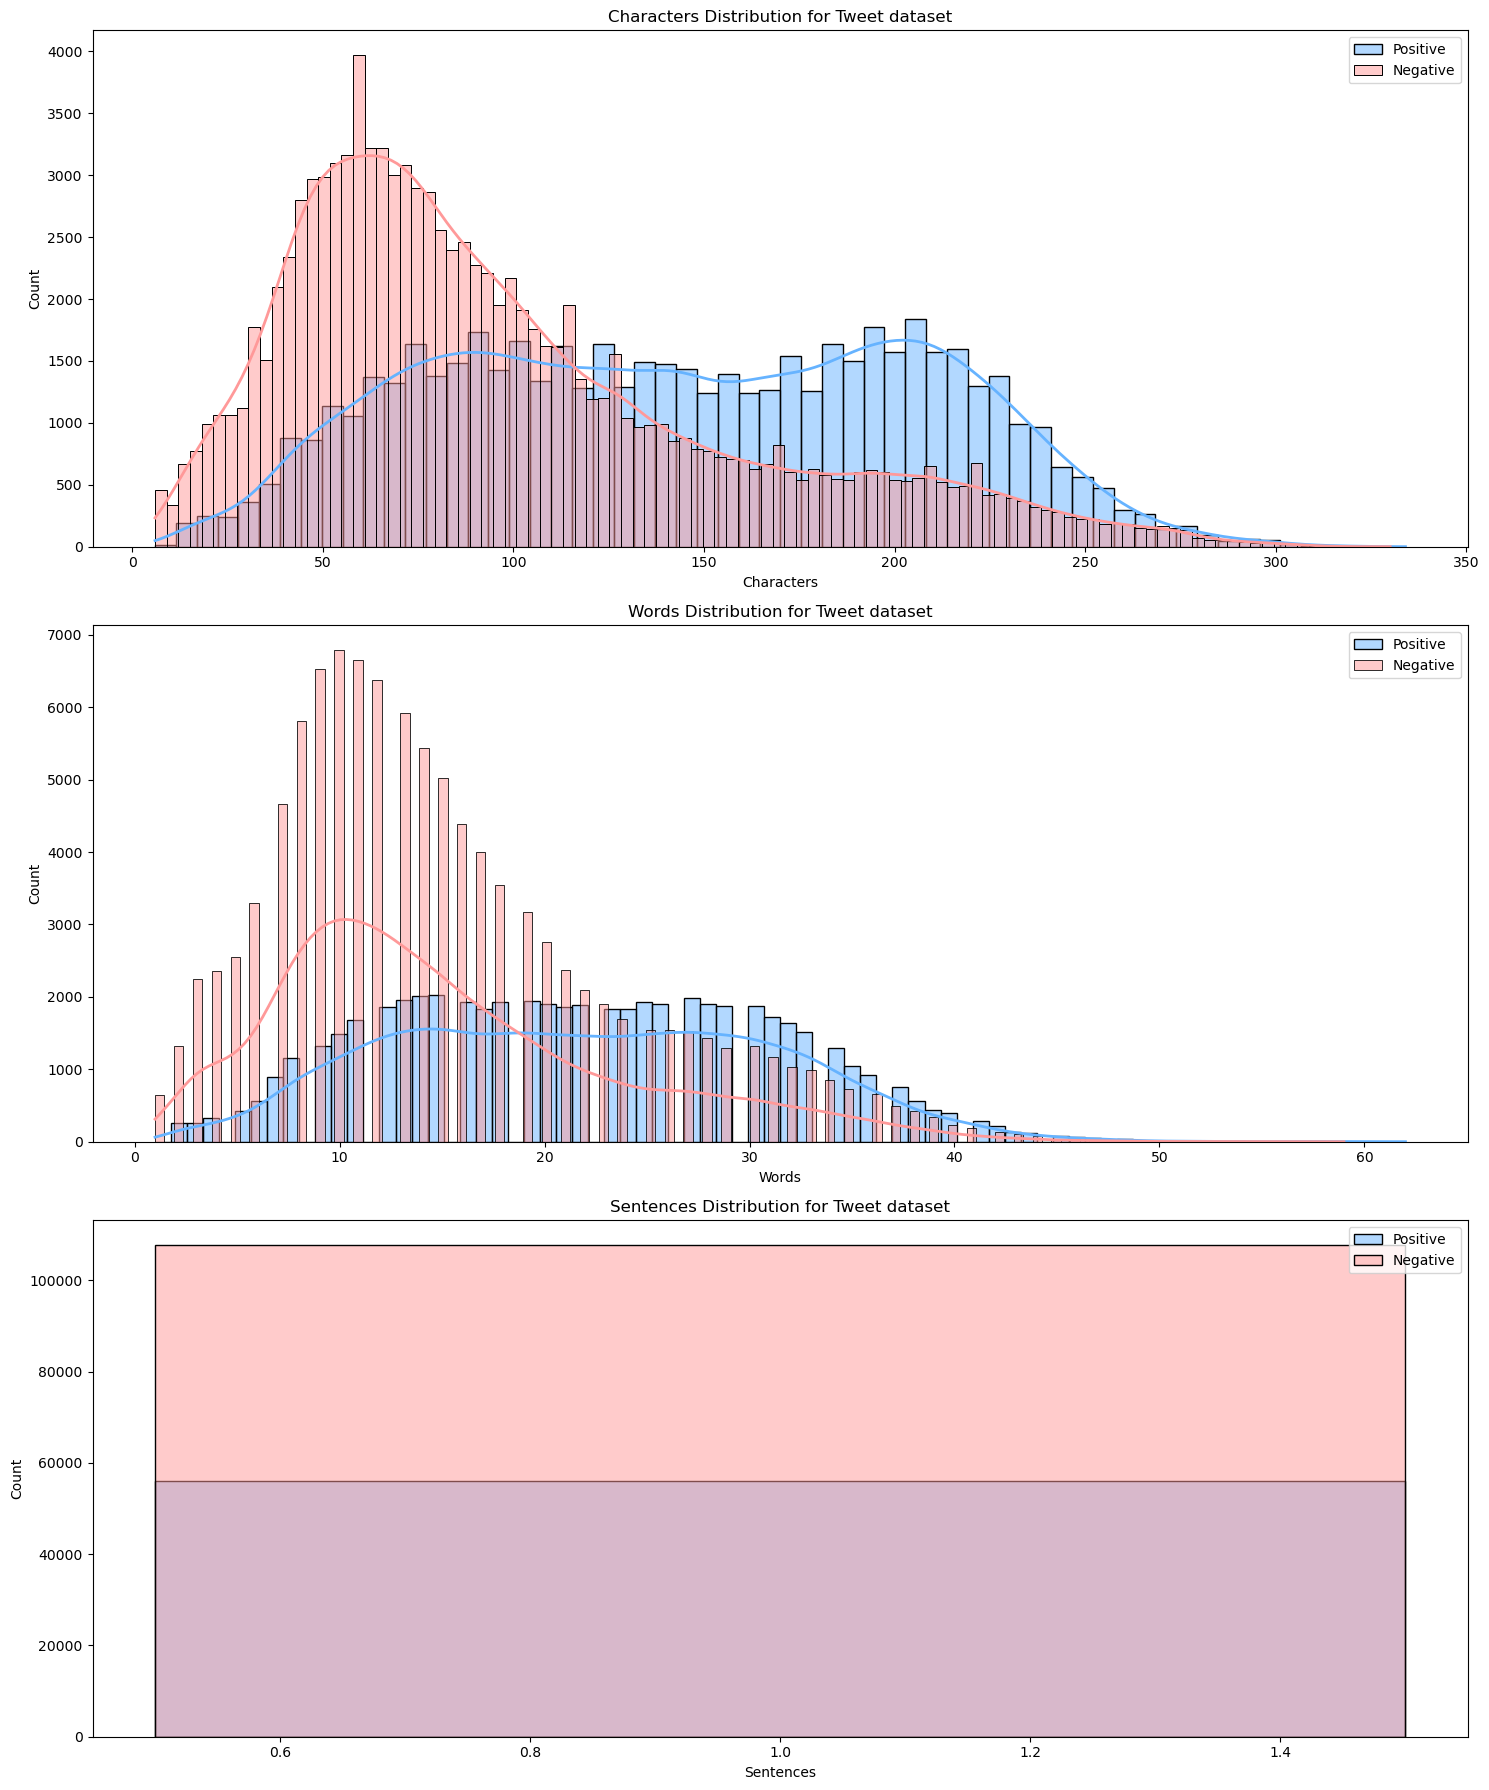

In [75]:
# List of features to plot
features = ["Characters", "Words", "Sentences"]

# Call the function
plot_distribution_features(df, features, "Tweet")

In [76]:
df['text_length'] = df['tweets'].apply(lambda x: len(x.split()))

# Determine the 95th percentile of these lengths
sequence_length_95 = np.percentile(df['text_length'], 95)

sequence_length = int(np.ceil(sequence_length_95))

print(f"Length covering at least 95% of the Tweets: {sequence_length}")
df = df.drop(columns=["text_length"])
print("The kept sequence is:", sequence_length, "words")

Length covering at least 95% of the Tweets: 35
The kept sequence is: 35 words


In [ ]:
max_features = 10000

vectorization = TextVectorization(standardize="lower_and_strip_punctuation", 
                                  max_tokens=max_features, 
                                  output_mode='int', 
                                  output_sequence_length=sequence_length)
vectorization.adapt(df["tweets"])

words_database = vectorization.get_vocabulary()
database_index = {word: index for index, word in enumerate(words_database)}

In [83]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding
import numpy as np
from tqdm import tqdm

# Define max_features and sequence length
max_features = 20000
sequence_length = 100

# Tokenizer to generate word index
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['tweets'])
database_index = tokenizer.word_index

# Load GloVe embeddings
def load_glove_index():
    EMBEDDING_FILE = 'glove.twitter.27B.200d.txt'
    def get_coefs(word, *arr): return word, np.asarray(arr, dtype='float32')
    embeddings_index = dict(get_coefs(*o.split(" ")) for o in open(EMBEDDING_FILE, 'r', encoding='utf-8'))
    return embeddings_index

glove_embedding_index_twitter = load_glove_index()

# Create embedding matrix
def create_glove(word_index, embeddings_index):
    all_embs = list(embeddings_index.values())
    embed_size = all_embs[0].shape[0]
    nb_words = min(max_features, len(word_index))
    embedding_matrix = np.random.normal(0, 1, (nb_words, embed_size))

    count_found = nb_words
    for word, i in tqdm(word_index.items()):
        if i >= max_features: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None: 
            embedding_matrix[i] = embedding_vector
        else:
            if word.islower():
                embedding_vector = embeddings_index.get(word.capitalize())
                if embedding_vector is not None: 
                    embedding_matrix[i] = embedding_vector
                else:
                    count_found -= 1
            else:
                count_found -= 1
    print("We found", count_found, "words")
    return embedding_matrix

adapted_glove_twitter = create_glove(database_index, glove_embedding_index_twitter)

# Define embedding layer
embedding_dim = 200
embedding_layer = Embedding(
    input_dim=max_features, 
    output_dim=embedding_dim, 
    weights=[adapted_glove_twitter], 
    input_length=sequence_length, 
    trainable=False
)

100%|██████████| 207138/207138 [00:00<00:00, 3266287.24it/s]
/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2024-12-11 21:16:27.210685: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


We found 10219 words


[1]Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.

[1]Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Convince me that your train/test splitting method is a realistic mirroring of how an algorithm would be used in practice. 

__Modeling__

[3]Investigate at least two different sequential network architectures (e.g., a CNN and a Transformer). Alternatively, you may also choose a recurrent network and Transformer network. Be sure to use an embedding layer (try to use a pre-trained embedding, if possible). Adjust one hyper-parameter of each network to potentially improve generalization performance (train a total of at least four models). Visualize the performance of training and validation sets versus the training iterations, showing that the models converged.

[1]Using the best parameters and architecture from the Transformer in the previous step, add a second Multi-headed self attention layer to your network. That is, the input to the second attention layer should be the output sequence of the first attention layer.  Visualize the performance of training and validation sets versus the training iterations, showing that the model converged.

[2]Use the method of train/test splitting and evaluation criteria that you argued for at the beginning of the lab. Visualize the results of all the models you trained.  Use proper statistical comparison techniques to determine which method(s) is (are) superior.  


__Exceptional Work__

[1]Use the pre-trained ConceptNet Numberbatch embedding and compare to pre-trained GloVe. Which method is better for your specific application?